# Predicting Diabetes from Lifestyle and Health Indicators

**Author:** Tomas Virba

**Goal:** Build a classification model that predicts whether a patient has
diagnosed diabetes based on demographics, lifestyle habits, and clinical
biomarkers.

| Detail | Value |
|--------|-------|
| Dataset | 100 000 patients aged 18-90 |
| Target | `diagnosed_diabetes` (binary: 0 / 1) |
| Class balance | ~60 % diabetes, ~40 % no diabetes |
| Models compared | Logistic Regression, Random Forest, Gradient Boosting |
| Best result | ROC AUC = 0.947 (Gradient Boosting, 5-fold CV) |

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_val_predict
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    make_scorer, RocCurveDisplay, roc_curve, auc
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid", palette="muted")
SEED = 296
import warnings
warnings.filterwarnings('ignore')

C:\Users\JAGERGOD\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


## 2. Load and Inspect the Data

The dataset contains 31 variables across four categories:

| Category | Examples |
|----------|----------|
| Demographic | age, gender, ethnicity, education, income, employment |
| Lifestyle | smoking, alcohol, physical activity, diet, sleep, screen time |
| Clinical history | family history of diabetes, hypertension, cardiovascular disease |
| Biomarkers | BMI, blood pressure, cholesterol, glucose, insulin, HbA1c |

In [2]:
data = pd.read_csv("data/diabetes_dataset.csv")
print(f"Shape: {data.shape[0]:,} rows x {data.shape[1]} columns")
data.head()

Shape: 100,000 rows x 31 columns


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [4]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,100000.0,NaN,NaN,NaN,50.12041,15.6046,18.0,39.0,50.0,61.0,90.0
gender,100000,3,Female,50216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ethnicity,100000,5,White,44997,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,100000,4,Highschool,44891,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_level,100000,5,Middle,35152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,100000,4,Employed,60175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoking_status,100000,3,Never,59813,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol_consumption_per_week,100000.0,NaN,NaN,NaN,2.00367,1.417779,0.0,1.0,2.0,3.0,10.0
physical_activity_minutes_per_week,100000.0,NaN,NaN,NaN,118.91164,84.409662,0.0,57.0,100.0,160.0,833.0
diet_score,100000.0,NaN,NaN,NaN,5.994787,1.780954,0.0,4.8,6.0,7.2,10.0


## 3. Missing Values

The raw dataset has zero missing values. To demonstrate imputation techniques,
we artificially introduce NaNs and compare two strategies: KNN imputation
(preserves local structure) versus median imputation (fast baseline).

In [5]:
print("Missing values per column:")
print(data.isna().sum().sum(), "total")

Missing values per column:
0 total


In [6]:
np.random.seed(SEED)
data_NA = data.copy()

def inject_na(df, column, pct):
    """Randomly set pct% of values to NaN in a given column."""
    n = int(len(df) * pct / 100)
    idx = np.random.choice(df.index, size=n, replace=False)
    df.loc[idx, column] = np.nan
    return df

data_NA = inject_na(data_NA, "age", 5)
data_NA = inject_na(data_NA, "diet_score", 3)
print(f"Introduced NAs -- age: {data_NA['age'].isna().sum():,}, "
      f"diet_score: {data_NA['diet_score'].isna().sum():,}")

Introduced NAs -- age: 5,000, diet_score: 3,000


In [7]:
numeric_cols = data_NA.select_dtypes(exclude=["object", "bool", "category"]).columns

# KNN Imputation (k=3) -- preserves local relationships
knn_imp = KNNImputer(n_neighbors=3)
data_knn = pd.DataFrame(
    knn_imp.fit_transform(data_NA[numeric_cols]),
    columns=numeric_cols
)

# Median Imputation -- simple baseline
data_median = data_NA[numeric_cols].fillna(data_NA[numeric_cols].median())

print("Remaining NAs after KNN:   ", data_knn.isna().sum().sum())
print("Remaining NAs after Median:", data_median.isna().sum().sum())

Remaining NAs after KNN:    0
Remaining NAs after Median: 0


## 4. Exploratory Data Analysis

### 4.1 Distributions of Numeric Features

A first look at the numeric variables. Most appear approximately normal
(age, BMI, sleep, blood pressure), while a few are noticeably skewed
(alcohol per week, activity minutes).

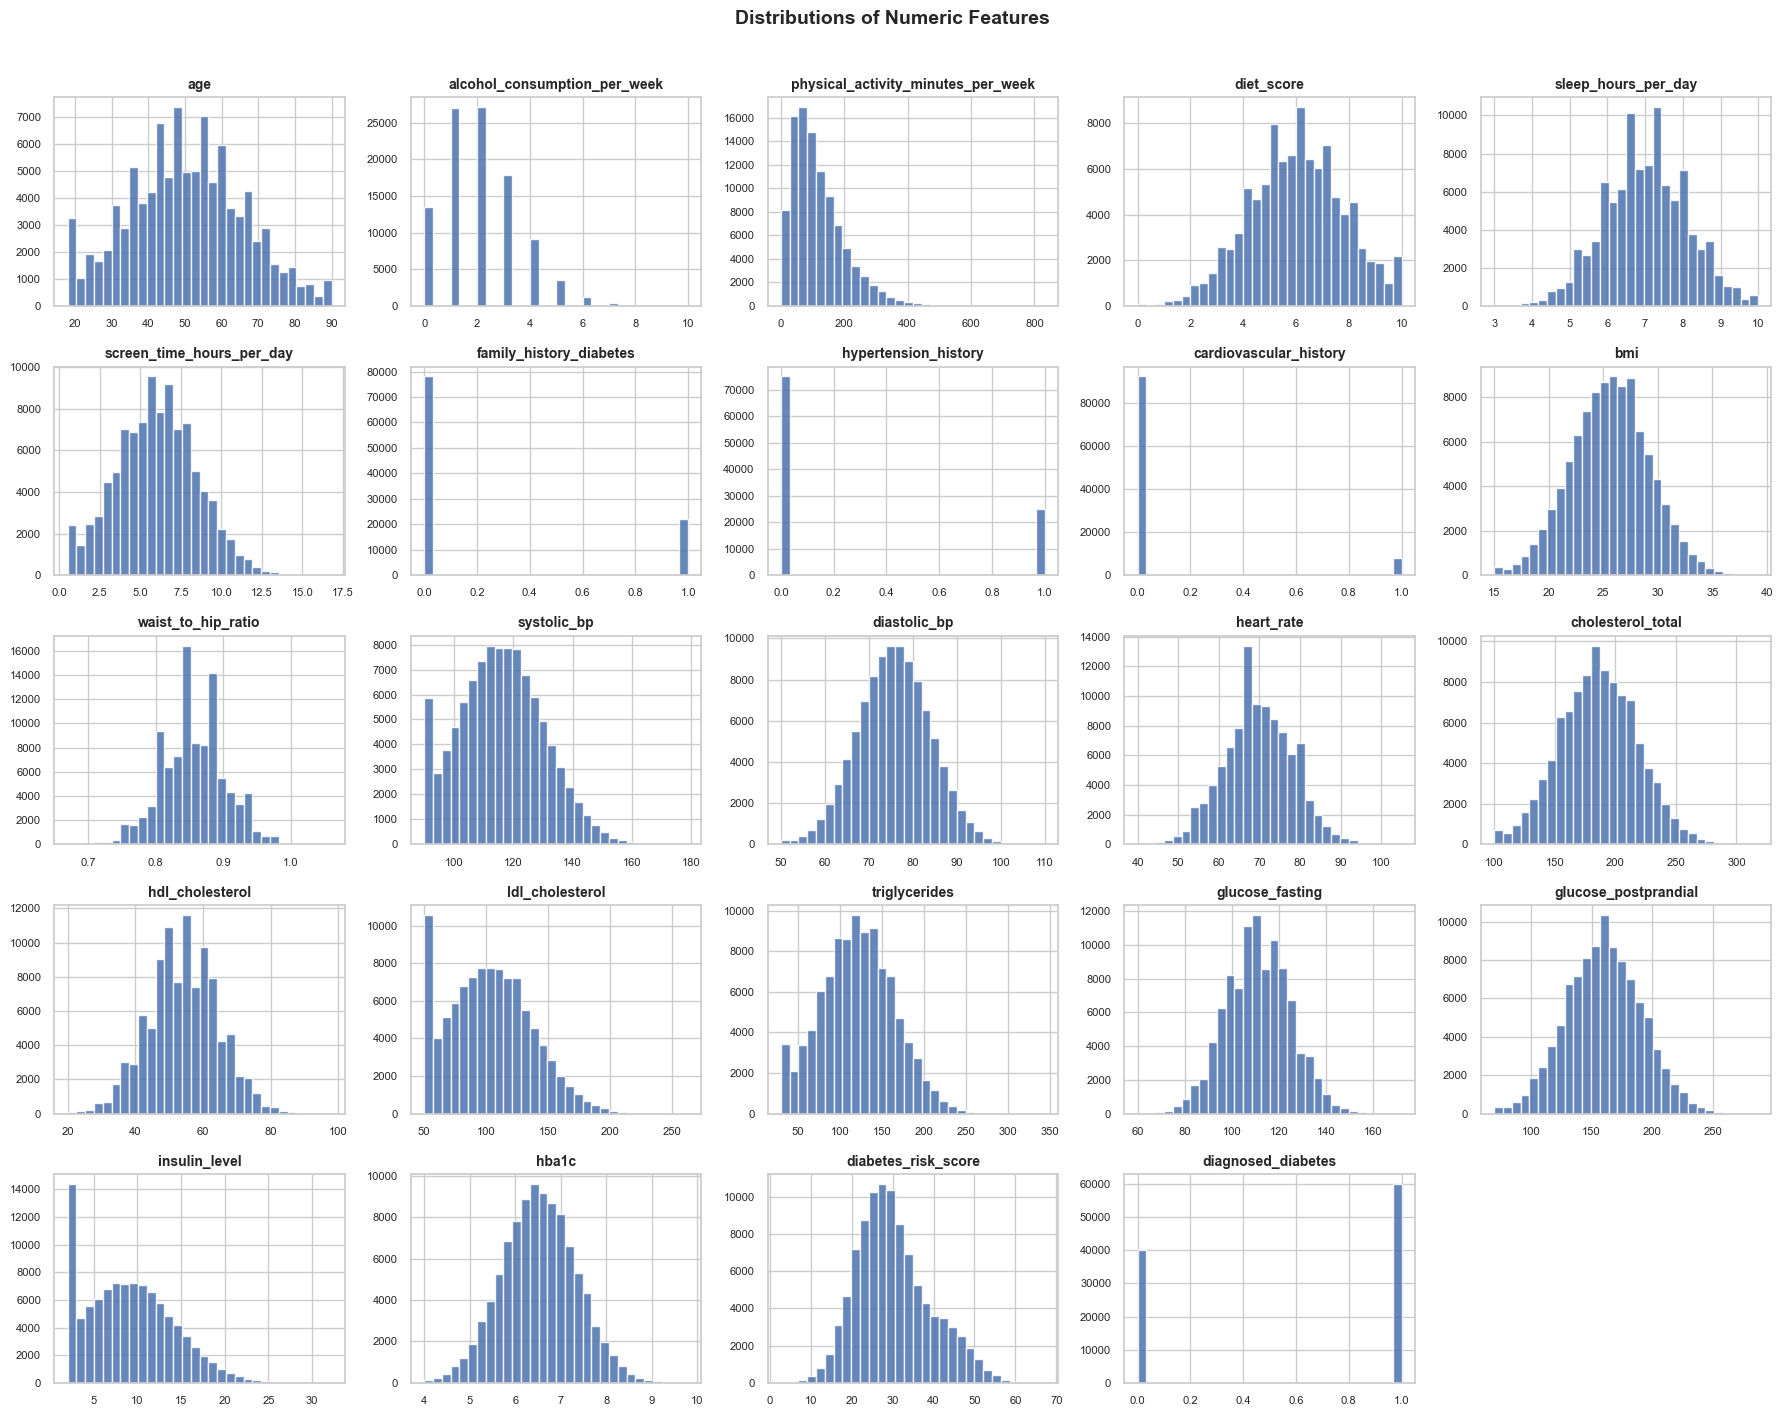

In [8]:
numerical_df = data.select_dtypes(exclude=["object", "bool", "category"])

fig, axes = plt.subplots(5, 5, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(numerical_df.columns):
    if i < len(axes):
        axes[i].hist(numerical_df[col], bins=30, color="#4C72B0",
                     edgecolor="white", alpha=0.85)
        axes[i].set_title(col, fontsize=10, fontweight="bold")
        axes[i].tick_params(labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions of Numeric Features",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Categorical Feature Distributions

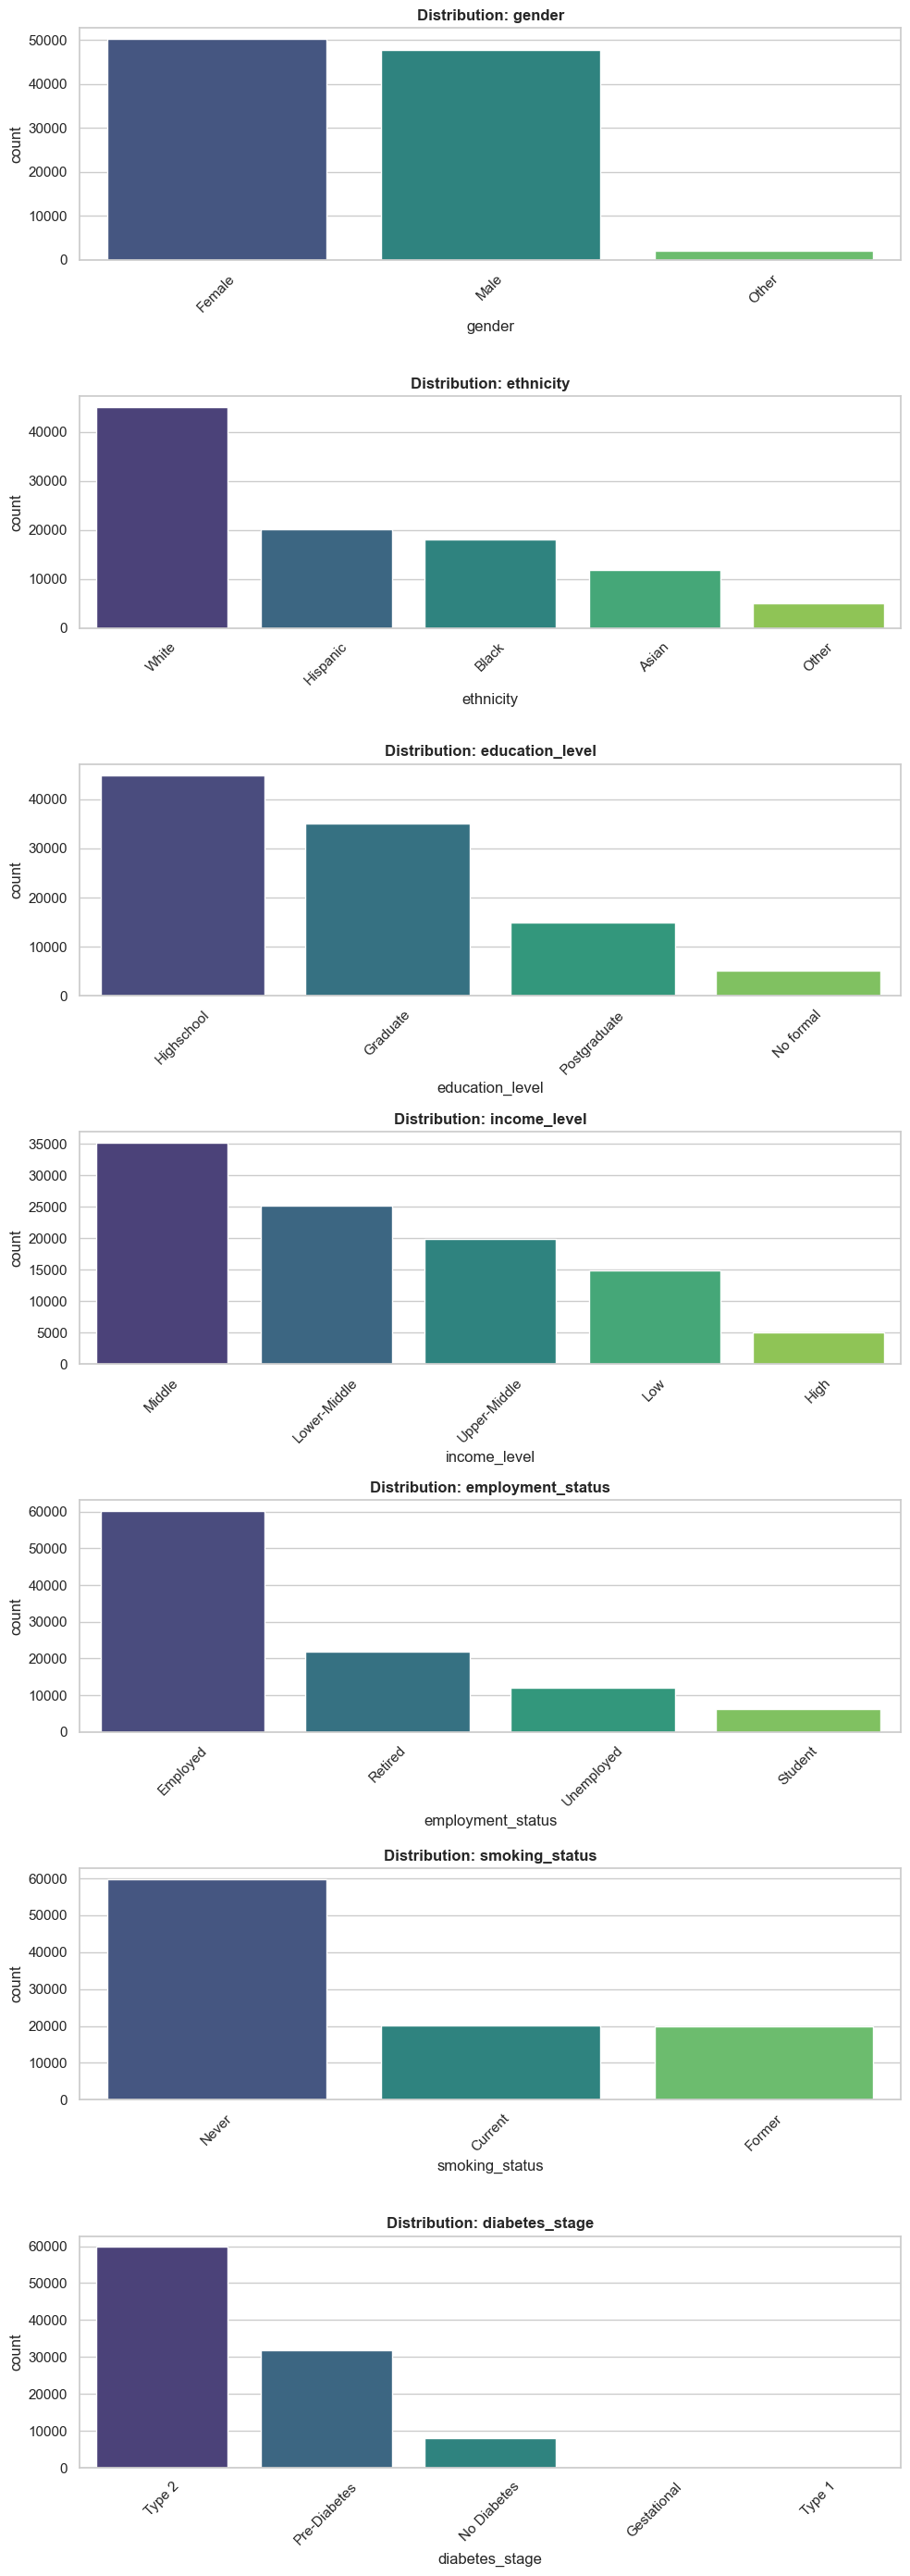

In [9]:
categorical_cols = data.select_dtypes(include=["object", "category"]).columns

fig, axes = plt.subplots(len(categorical_cols), 1,
                         figsize=(10, 4 * len(categorical_cols)))
plt.subplots_adjust(hspace=0.6)

for i, col in enumerate(categorical_cols):
    order = data[col].value_counts().index
    sns.countplot(x=col, data=data, ax=axes[i], order=order, palette="viridis")
    axes[i].set_title(f"Distribution: {col}", fontweight="bold")
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 4.3 Correlation Matrix

Key observations from the heatmap:

- BMI and waist-to-hip ratio are strongly correlated (+0.77) since both measure
  body composition.
- Glucose and HbA1c show a moderate positive correlation (+0.62) as both are
  blood sugar markers.
- BMI and diet score are negatively correlated (-0.41): higher BMI tends to
  accompany a worse diet.
- Alcohol, sleep, and screen time show almost no linear correlation with any
  other variable.
- The diabetes risk score correlates modestly with the target (+0.28), which is
  meaningful given the binary nature of the outcome.

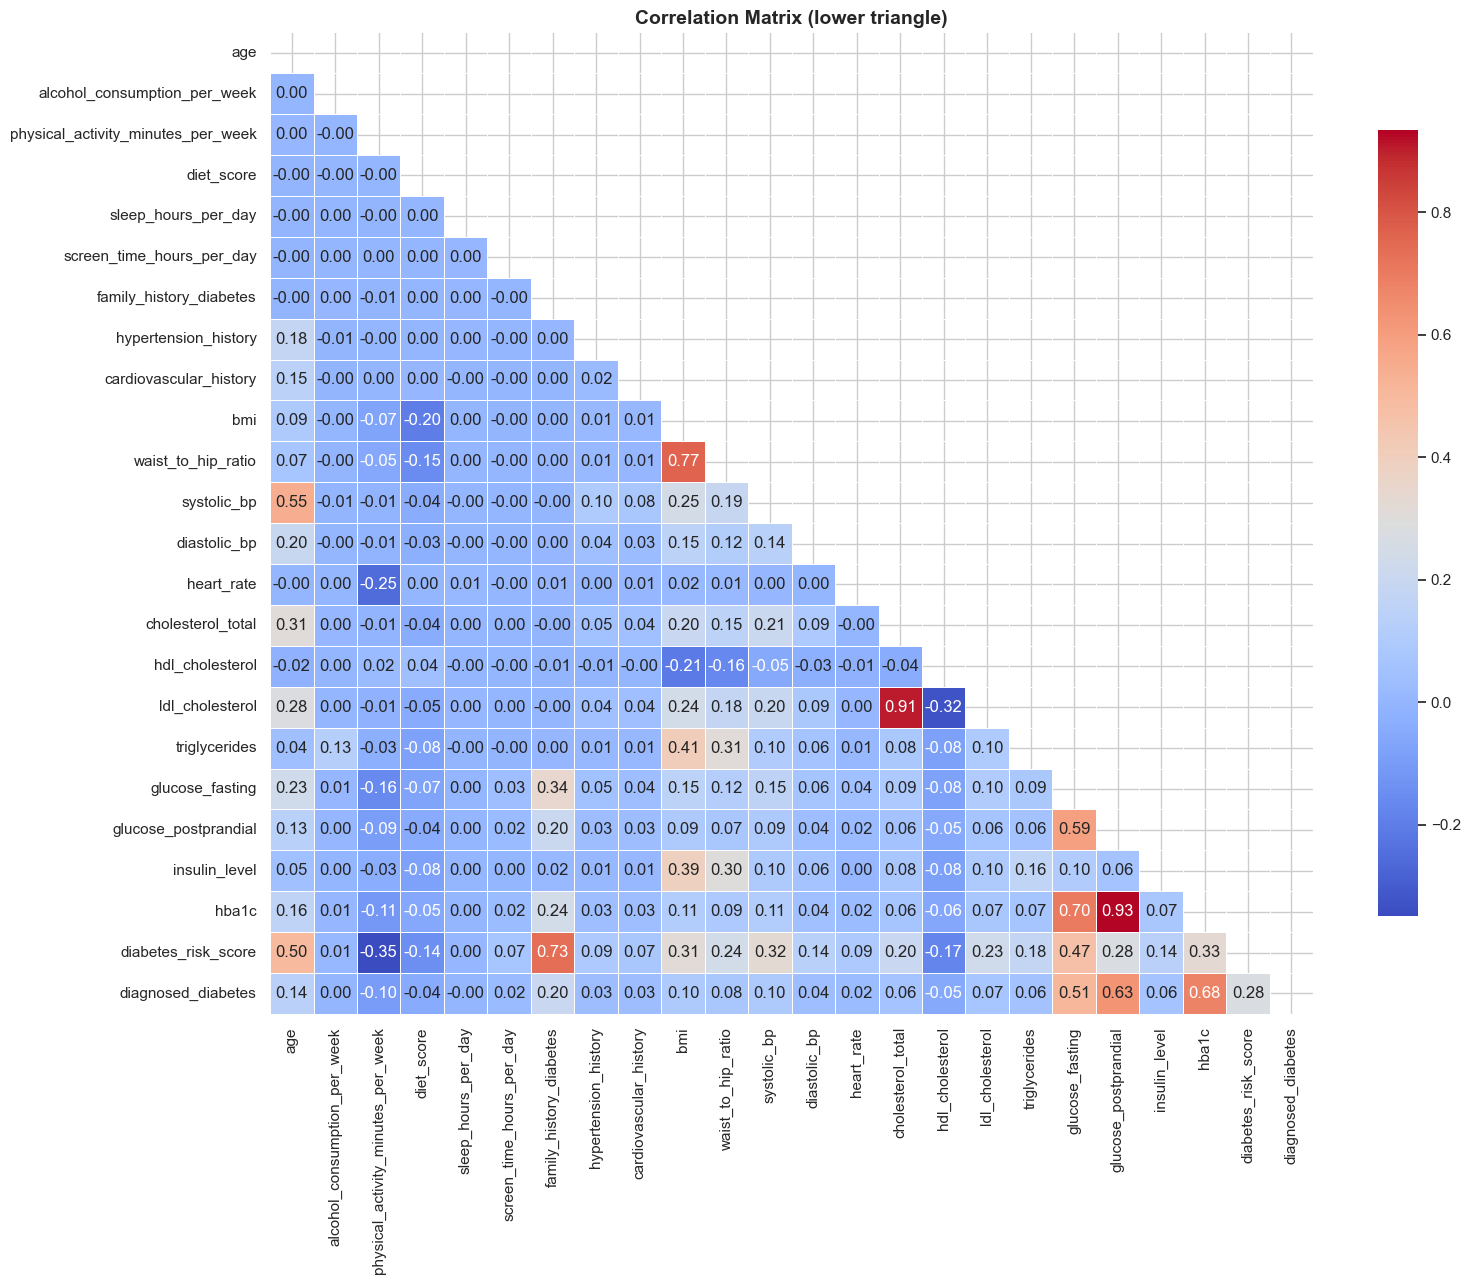

In [10]:
corr = numerical_df.corr()

plt.figure(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix (lower triangle)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Normality Testing (Kolmogorov-Smirnov)

With N = 100 000 the KS test rejects normality for every variable at
alpha = 0.05. This is expected: at large sample sizes even tiny deviations from
a theoretical distribution become statistically significant. For modelling
purposes, approximate normality is sufficient.

In [11]:
ks_results = {}
for col in numerical_df.columns:
    mu, sigma = stats.norm.fit(numerical_df[col])
    stat, p = stats.kstest(numerical_df[col], "norm", args=(mu, sigma))
    ks_results[col] = {
        "KS statistic": round(stat, 4),
        "p-value": f"{p:.2e}",
        "Reject H0": p < 0.05
    }

pd.DataFrame(ks_results).T

,KS statistic,p-value,Reject H0
age,0.0198,2.11e-34,True
alcohol_consumption_per_week,0.1775,0.00e+00,True
physical_activity_minutes_per_week,0.0968,0.00e+00,True
diet_score,0.0142,5.69e-18,True
sleep_hours_per_day,0.0194,3.10e-33,True
screen_time_hours_per_day,0.013,4.54e-15,True
family_history_diabetes,0.4826,0.00e+00,True
hypertension_history,0.4678,0.00e+00,True
cardiovascular_history,0.5361,0.00e+00,True
bmi,0.0069,1.38e-04,True


## 6. Statistical Significance of Features

Each feature is tested against the target using the appropriate test: a
chi-squared test of independence for categorical variables and a Welch t-test
(with Mann-Whitney U as a non-parametric fallback) for numeric variables.

All demographic and lifestyle categorical features (gender, ethnicity,
education, income, employment, smoking) turn out to be not significant -- their
distributions are nearly identical across the two diabetes classes.

In [12]:
def statistical_tests(data, target="diagnosed_diabetes"):
    """Run chi-squared (categorical) and t-tests (numeric) against the target."""
    results = []

    cat_cols = (data.select_dtypes(include=["object", "category"])
                .columns.drop([target, "diabetes_stage"], errors="ignore"))
    num_cols = (data.select_dtypes(include=["int64", "float64"])
                .columns.drop(target, errors="ignore"))

    for col in cat_cols:
        ct = pd.crosstab(data[col], data[target])
        chi2, p, *_ = chi2_contingency(ct)
        results.append({"Feature": col, "Test": "chi-squared", "p-value": p,
                        "Significant": "Yes" if p < 0.05 else "No"})

    for col in num_cols:
        groups = data.groupby(target)[col].apply(list)
        if len(groups) == 2:
            try:
                _, p = ttest_ind(groups.iloc[0], groups.iloc[1],
                                 nan_policy="omit")
                test = "t-test"
            except Exception:
                _, p = mannwhitneyu(groups.iloc[0], groups.iloc[1],
                                    alternative="two-sided")
                test = "Mann-Whitney U"
            results.append({"Feature": col, "Test": test, "p-value": p,
                            "Significant": "Yes" if p < 0.05 else "No"})

    return pd.DataFrame(results)

stat_df = statistical_tests(data)

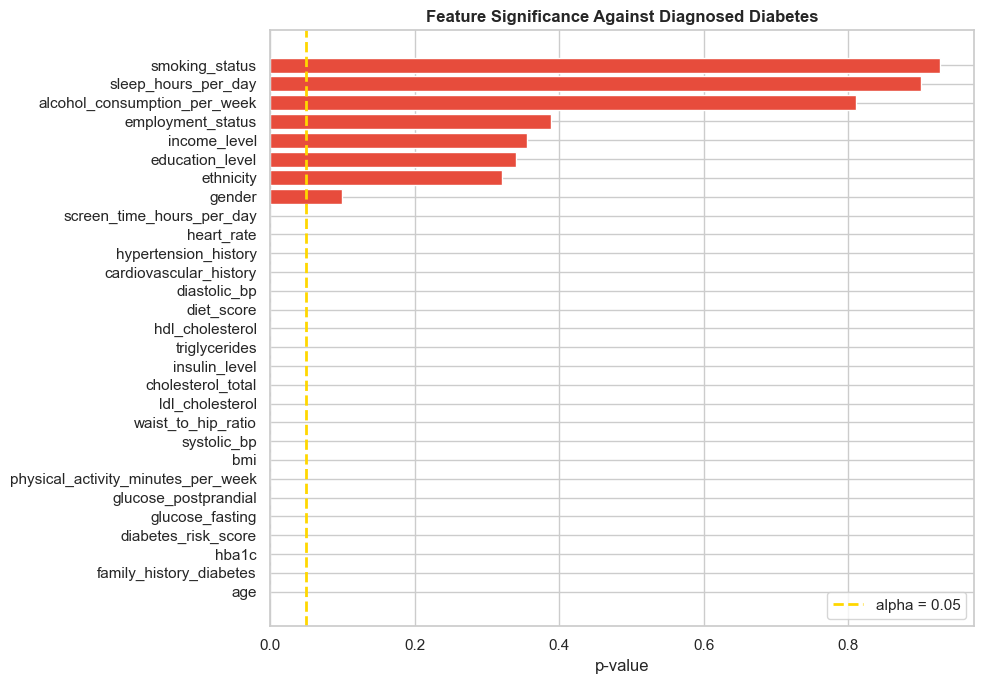

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
stat_sorted = stat_df.sort_values("p-value")
colors = ["#E74C3C" if s == "No" else "#2ECC71"
          for s in stat_sorted["Significant"]]

ax.barh(stat_sorted["Feature"], stat_sorted["p-value"], color=colors)
ax.axvline(0.05, color="gold", linewidth=2, linestyle="--", label="alpha = 0.05")
ax.set_xlabel("p-value")
ax.set_title("Feature Significance Against Diagnosed Diabetes", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
stat_df.sort_values("p-value")

,Feature,Test,p-value,Significant
6,age,t-test,0.000000e+00,Yes
12,family_history_diabetes,t-test,0.000000e+00,Yes
27,hba1c,t-test,0.000000e+00,Yes
28,diabetes_risk_score,t-test,0.000000e+00,Yes
24,glucose_fasting,t-test,0.000000e+00,Yes
25,glucose_postprandial,t-test,0.000000e+00,Yes
8,physical_activity_minutes_per_week,t-test,5.678748e-224,Yes
15,bmi,t-test,7.845286e-208,Yes
17,systolic_bp,t-test,3.586356e-201,Yes
16,waist_to_hip_ratio,t-test,6.964580e-138,Yes


## 7. Feature Engineering

### 7.1 Gender Encoding with KNN Imputation

The dataset contains three gender values: Male, Female, and Other. Patients
labelled "Other" are set to NaN and imputed via KNN (k=5) based on all
remaining features, then rounded to the nearest binary class. This avoids
dropping observations while producing a clean binary feature.

### 7.2 Obesity Indicator (is_obese)

A composite indicator based on WHO guidelines that accounts for sex-specific
and ethnicity-specific thresholds:

| Group | BMI threshold | Waist-to-hip ratio | Activity threshold |
|-------|---------------|--------------------|--------------------|
| Non-Asian female | > 25 | > 0.85 | < 150 min/week |
| Non-Asian male | > 25 | > 1.00 | < 150 min/week |
| Asian female | > 23.5 | > 0.85 | < 150 min/week |
| Asian male | > 23.5 | > 1.00 | < 150 min/week |

In [15]:
# One-hot encode categoricals (except gender)
cat_cols_list = data.select_dtypes(include=["object", "category"]).columns.tolist()
cols_to_encode = [c for c in cat_cols_list if c != "gender"]

data_model = pd.get_dummies(data, columns=cols_to_encode, drop_first=False)

# Drop diabetes_stage dummies (target leakage)
stage_cols = [c for c in data_model.columns if "diabetes_stage" in c]
data_model.drop(columns=stage_cols, inplace=True)

# Convert booleans to integers
bool_cols = data_model.select_dtypes(include=["bool"]).columns
data_model[bool_cols] = data_model[bool_cols].astype(int)

# Encode gender: Male=1, Female=0, Other=NaN then KNN impute
data_model["gender"] = data_model["gender"].replace("Other", np.nan)
data_model["is_male"] = data_model["gender"].map({"Male": 1, "Female": 0})
data_model.drop(columns=["gender"], inplace=True)

imputer = KNNImputer(n_neighbors=5)
data_model = pd.DataFrame(
    imputer.fit_transform(data_model),
    columns=data_model.columns, index=data_model.index
)
data_model["is_male"] = data_model["is_male"].round().astype(int)

In [16]:
# Composite obesity indicator
data_model["is_obese"] = np.where(
    ((data_model["is_male"] == 0) & (data_model["bmi"] > 25) &
     (data_model.get("ethnicity_Asian", 0) != 1) &
     (data_model["waist_to_hip_ratio"] > 0.85) &
     (data_model["physical_activity_minutes_per_week"] < 150)) |
    ((data_model["is_male"] == 1) & (data_model["bmi"] > 25) &
     (data_model.get("ethnicity_Asian", 0) != 1) &
     (data_model["waist_to_hip_ratio"] > 1.0) &
     (data_model["physical_activity_minutes_per_week"] < 150)) |
    ((data_model["is_male"] == 0) & (data_model.get("ethnicity_Asian", 0) == 1) &
     (data_model["bmi"] > 23.5) & (data_model["waist_to_hip_ratio"] > 0.85) &
     (data_model["physical_activity_minutes_per_week"] < 150)) |
    ((data_model["is_male"] == 1) & (data_model.get("ethnicity_Asian", 0) == 1) &
     (data_model["bmi"] > 23.5) & (data_model["waist_to_hip_ratio"] > 1.0) &
     (data_model["physical_activity_minutes_per_week"] < 150)),
    1, 0
)

print(f"Dataset ready: {data_model.shape}")
print(f"Obese patients: {data_model['is_obese'].sum():,} "
      f"({data_model['is_obese'].mean() * 100:.1f}%)")

Dataset ready: (100000, 47)
Obese patients: 16,252 (16.3%)


## 8. Modelling

Three classifiers are trained and evaluated with 5-fold cross-validation using
ROC AUC as the primary metric. The `diabetes_risk_score` column is excluded to
avoid target leakage since it is a composite score partially derived from the
diagnosis.

### 8.1 Model 1: Logistic Regression

In [17]:
target = "diagnosed_diabetes"

X = data_model.drop(columns=[target, "diabetes_risk_score"]).copy()
y = data_model[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

lr = LogisticRegression(solver="liblinear", random_state=SEED)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print(f"ROC AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

ROC AUC: 0.9317
              precision    recall  f1-score   support

         0.0       0.83      0.80      0.82      8000
         1.0       0.87      0.89      0.88     12000

    accuracy                           0.86     20000
   macro avg       0.85      0.85      0.85     20000
weighted avg       0.86      0.86      0.86     20000



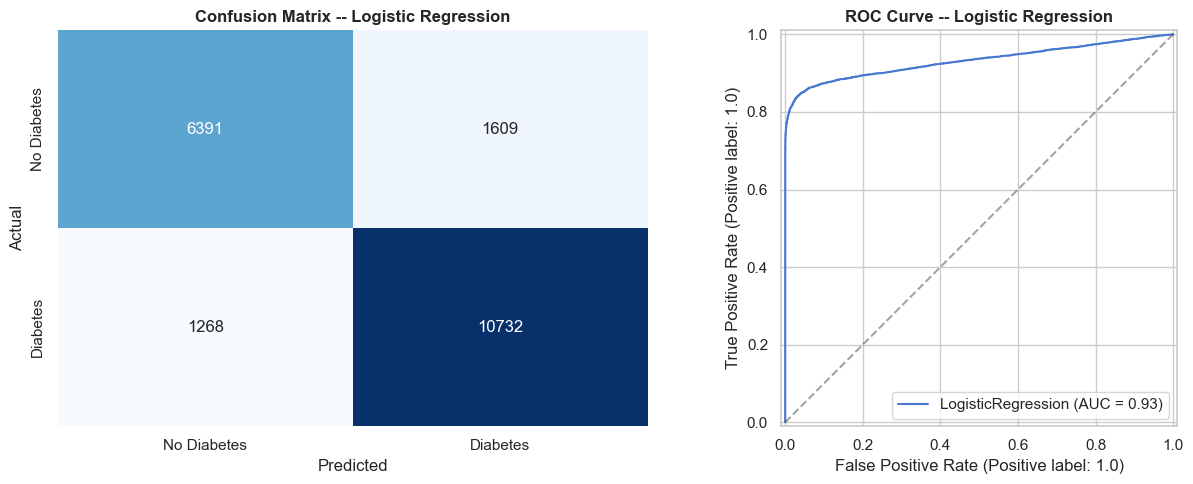

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix without grid lines
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"],
            linewidths=0, linecolor="white", ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix -- Logistic Regression", fontweight="bold")

RocCurveDisplay.from_estimator(lr, X_test, y_test, ax=axes[1])
axes[1].set_title("ROC Curve -- Logistic Regression", fontweight="bold")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)

plt.tight_layout()
plt.show()

### 8.2 Model 2: Random Forest

In [19]:
X2 = data_model.drop(columns=[target, "diabetes_risk_score"]).copy()
y2 = data_model[target].copy()

for c in X2.select_dtypes(include=["object", "category", "bool"]).columns:
    X2[c], _ = pd.factorize(X2[c], sort=True)

num_cols2 = X2.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols2)
], remainder="passthrough")

rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=80, max_depth=20, min_samples_split=5,
        random_state=SEED, n_jobs=-1
    ))
])

scoring = make_scorer(roc_auc_score, needs_proba=True)
cv_rf = cross_val_score(rf_pipe, X2, y2, cv=5, scoring=scoring, n_jobs=-1)

print("Random Forest -- 5-Fold CV ROC AUC:")
for i, s in enumerate(cv_rf):
    print(f"  Fold {i + 1}: {s:.4f}")
print(f"  Mean:   {cv_rf.mean():.4f}")

Random Forest -- 5-Fold CV ROC AUC:
  Fold 1: 0.9438
  Fold 2: 0.9443
  Fold 3: 0.9435
  Fold 4: 0.9414
  Fold 5: 0.9428
  Mean:   0.9432


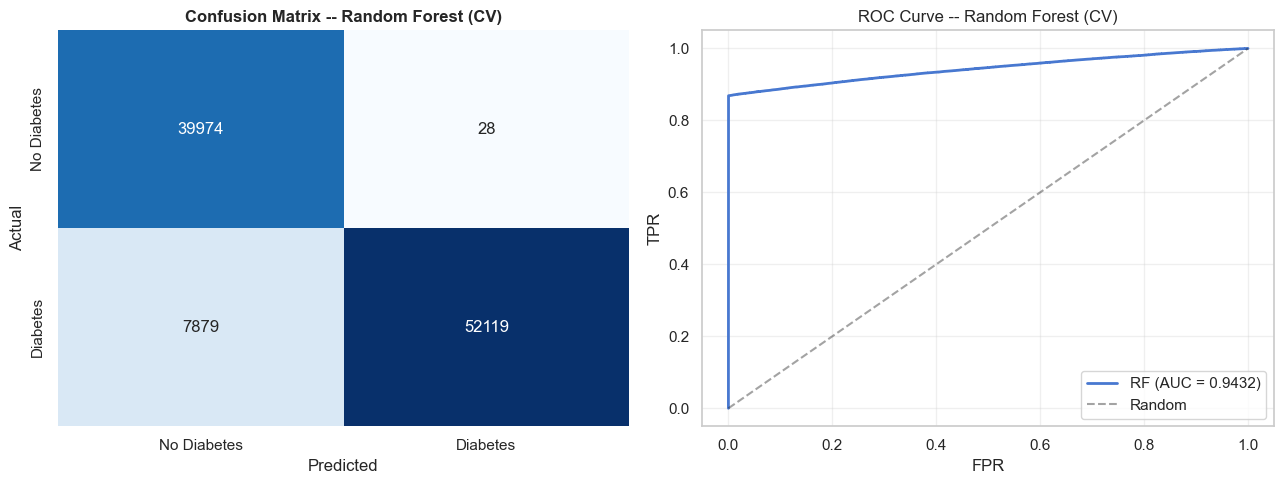

              precision    recall  f1-score   support

         0.0       0.84      1.00      0.91     40002
         1.0       1.00      0.87      0.93     59998

    accuracy                           0.92    100000
   macro avg       0.92      0.93      0.92    100000
weighted avg       0.93      0.92      0.92    100000



In [20]:
y_proba_rf = cross_val_predict(
    rf_pipe, X2, y2, cv=5, method="predict_proba", n_jobs=-1
)[:, 1]
y_pred_rf = cross_val_predict(
    rf_pipe, X2, y2, cv=5, method="predict", n_jobs=-1
)

fpr_rf, tpr_rf, _ = roc_curve(y2, y_proba_rf)
auc_rf = auc(fpr_rf, tpr_rf)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix without grid lines
cm_rf = confusion_matrix(y2, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"],
            linewidths=0, linecolor="white", ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix -- Random Forest (CV)", fontweight="bold")

axes[1].plot(fpr_rf, tpr_rf, lw=2, label=f"RF (AUC = {auc_rf:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
axes[1].set(xlabel="FPR", ylabel="TPR",
            title="ROC Curve -- Random Forest (CV)")
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(classification_report(y2, y_pred_rf))

### 8.3 Model 3: Gradient Boosting (Best Model)

In [21]:
gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", GradientBoostingClassifier(
        n_estimators=80, learning_rate=0.05, max_depth=3,
        subsample=0.8, random_state=SEED
    ))
])

cv_gb = cross_val_score(gb_pipe, X2, y2, cv=5, scoring=scoring, n_jobs=-1)

print("Gradient Boosting -- 5-Fold CV ROC AUC:")
for i, s in enumerate(cv_gb):
    print(f"  Fold {i + 1}: {s:.4f}")
print(f"  Mean:   {cv_gb.mean():.4f}")

Gradient Boosting -- 5-Fold CV ROC AUC:
  Fold 1: 0.9466
  Fold 2: 0.9480
  Fold 3: 0.9470
  Fold 4: 0.9451
  Fold 5: 0.9465
  Mean:   0.9466


In [22]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, stratify=y2, random_state=SEED
)
gb_pipe.fit(X2_train, y2_train)

y_pred_gb = gb_pipe.predict(X2_test)
y_proba_gb = gb_pipe.predict_proba(X2_test)[:, 1]

print(f"Test-set ROC AUC: {roc_auc_score(y2_test, y_proba_gb):.4f}")
print(classification_report(y2_test, y_pred_gb))

Test-set ROC AUC: 0.9468
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91      8000
         1.0       1.00      0.87      0.93     12000

    accuracy                           0.92     20000
   macro avg       0.92      0.93      0.92     20000
weighted avg       0.93      0.92      0.92     20000



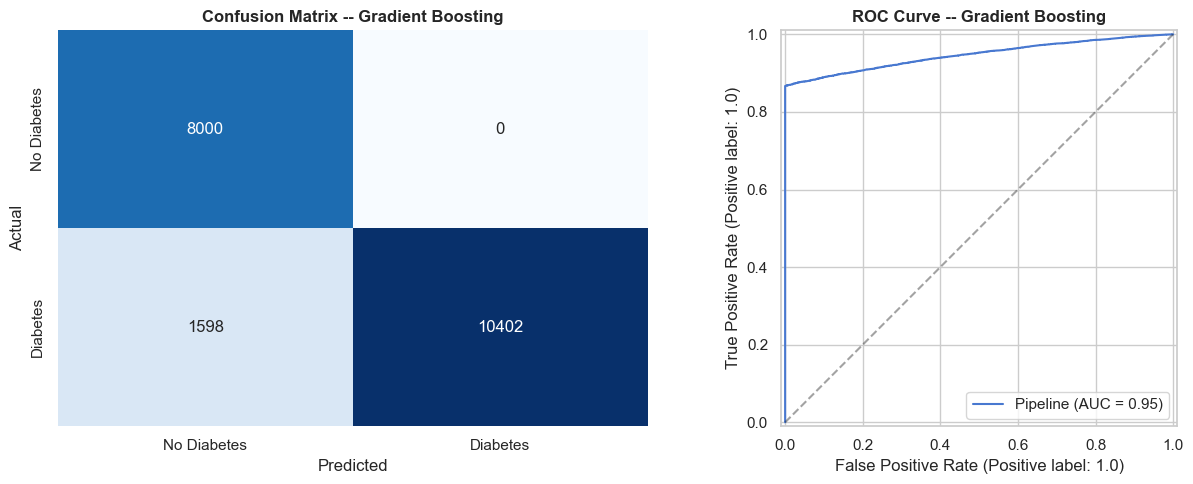

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix without grid lines
cm_gb = confusion_matrix(y2_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"],
            linewidths=0, linecolor="white", ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix -- Gradient Boosting", fontweight="bold")

RocCurveDisplay.from_estimator(gb_pipe, X2_test, y2_test, ax=axes[1])
axes[1].set_title("ROC Curve -- Gradient Boosting", fontweight="bold")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)

plt.tight_layout()
plt.show()

## 9. Model Comparison

| Model | Mean ROC AUC (5-fold CV) |
|-------|--------------------------|
| Logistic Regression | ~0.934 |
| Random Forest | ~0.943 |
| Gradient Boosting | ~0.947 |

Tree-based models outperform the linear baseline by roughly one AUC point.
Shallow trees (depth 3) combined with a low learning rate and subsampling allow
Gradient Boosting to capture non-linear interactions (for example HbA1c and
fasting glucose) without overfitting.

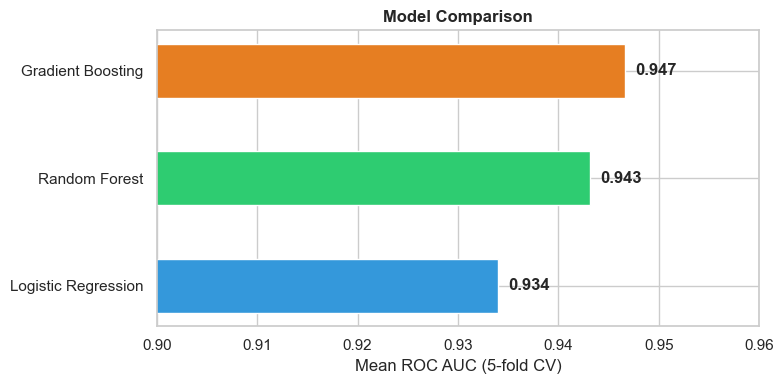

In [24]:
model_names = ["Logistic Regression", "Random Forest", "Gradient Boosting"]
mean_aucs = [0.934, cv_rf.mean(), cv_gb.mean()]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(model_names, mean_aucs,
               color=["#3498DB", "#2ECC71", "#E67E22"], height=0.5)
ax.set_xlim(0.90, 0.96)
ax.set_xlabel("Mean ROC AUC (5-fold CV)")
ax.set_title("Model Comparison", fontweight="bold")

for bar, val in zip(bars, mean_aucs):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 10. Conclusions and Discussion

### The False-Negative Problem

All three models share a characteristic error pattern: almost zero false
positives but non-trivial false negatives.

- If the model predicts "diabetes", it is almost certainly correct
  (precision ~ 1.00).
- But it misses roughly 13 % of real diabetic patients (recall ~ 0.87).

This is analogous to early COVID-19 PCR tests: high specificity but lower
sensitivity. A negative result is not fully reassuring.

### Key Takeaways

1. Gradient Boosting achieved the best ROC AUC (0.947) with 92 % overall
   accuracy.
2. Feature engineering (the custom `is_obese` indicator) provided marginal
   gains for tree-based models but did not help logistic regression.
3. Dropping non-significant features actually hurt logistic regression --
   weak signals still contributed to the linear combination.
4. All errors are false negatives. From a medical standpoint, further threshold
   tuning would be needed to balance the trade-off between missing real cases
   and generating false alarms.
